In [1]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2025-01-01")

df.reset_index(inplace=True)
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

df.head()

/tmp/ipykernel_2157/2612550068.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Date,Open,High,Low,Close,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2020-01-02,71.409793,72.460791,71.156689,72.400528,135480400
1,2020-01-03,71.629122,72.455935,71.472439,71.696617,146322800
2,2020-01-06,70.819201,72.306499,70.568503,72.267929,118387200
3,2020-01-07,72.277586,72.533103,71.708703,71.928062,108872000
4,2020-01-08,71.631559,73.386431,71.631559,73.085114,132079200


In [3]:
df["MA_5"] = df["Close"].rolling(window=5).mean()
df["MA_10"] = df["Close"].rolling(window=10).mean()

df["Daily_Return"] = df["Close"].pct_change()
df["Volatility_5"] = df["Daily_Return"].rolling(window=5).std()

df["Target"] = df["Close"].shift(-1)

df.dropna(inplace=True)

df.head()

Price,Date,Open,High,Low,Close,Volume,MA_5,MA_10,Daily_Return,Volatility_5,Target
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
9,2020-01-15,75.172645,76.052490,74.618217,75.049706,121923600,75.254115,73.764883,-0.004285,0.015547,75.989792
10,2020-01-16,75.592055,76.100682,75.230474,75.989792,108829200,75.524573,74.123809,0.012526,0.013709,76.831093
11,2020-01-17,76.238095,76.833498,75.931959,76.831093,137816400,75.929546,74.637257,0.011071,0.014044,76.310410
12,2020-01-21,76.459862,76.900987,76.173007,76.310410,110843200,75.910741,75.041505,-0.006777,0.011467,76.582794
13,2020-01-22,76.794915,77.134802,76.488780,76.582794,101832400,76.152759,75.506978,0.003569,0.008727,76.951653


In [4]:
features = ["Open", "High", "Low", "Close", "Volume", "MA_5", "MA_10", "Daily_Return", "Volatility_5"]

X = df[features]
y = df["Target"]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [6]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MAE: 2.1842642228456373
RMSE: 2.945906962652784
R^2: 0.9867020436187603


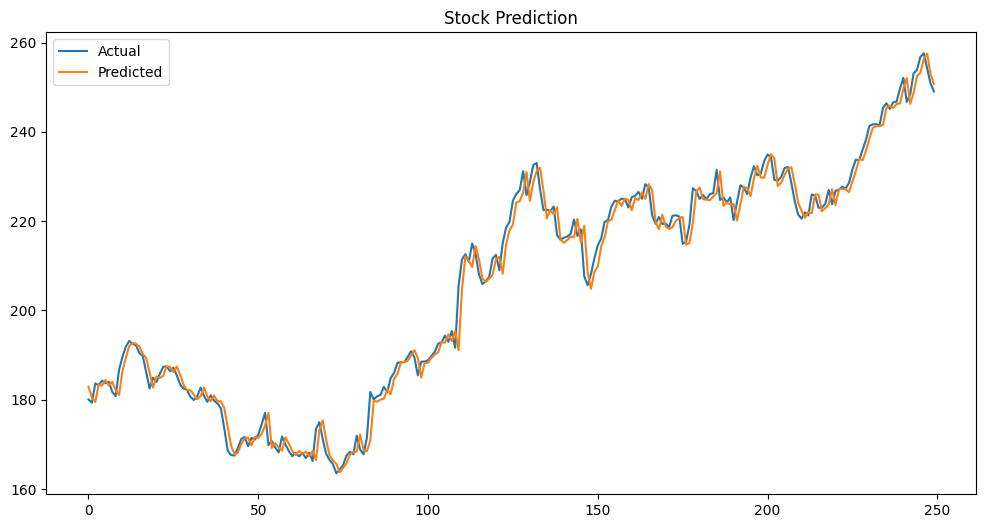

In [7]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Stock Prediction")
plt.show()